Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


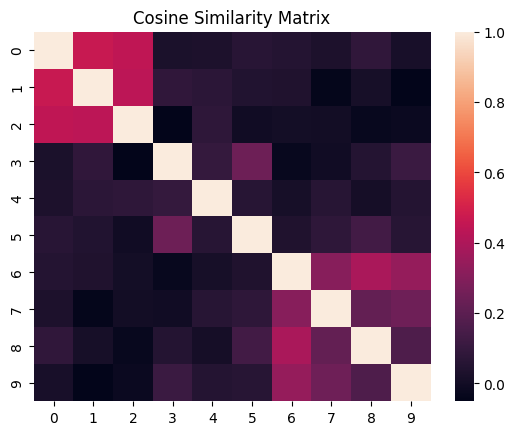

Top 2 similar sentences:

The bowler took three wickets in one over
Similarity Score: 1.0000001

Virat Kohli scored a century in the match
Similarity Score: 0.46225673



In [4]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

sentences = [

# Cricket (3 sentences)
"Virat Kohli scored a century in the match",
"The bowler took three wickets in one over",
"Cricket fans celebrated the team's victory",

# Cooking (3 sentences)
"Cooking pasta requires boiling water first",
"Adding spices improves the taste of food",
"Baking cakes requires precise temperature control",

# Cybersecurity (4 sentences)
"Cybersecurity protects systems from attacks",
"Phishing emails steal user credentials",
"Encryption secures sensitive data",
"Firewalls block unauthorized access"

]

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

sns.heatmap(similarity_matrix)
plt.title("Cosine Similarity Matrix")
plt.show()

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

top2 = scores.argsort()[-2:][::-1]

print("Top 2 similar sentences:\n")

for i in top2:
    print(sentences[i])
    print("Similarity Score:", scores[i])
    print()